In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

# Load Dataset
df = pd.read_csv('/content/gdrive/MyDrive/candidate_quality_improved.csv')

print("Shape Dataset:", df.shape)

Mounted at /content/gdrive
Shape Dataset: (5000, 11)


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load Dataset
df = pd.read_csv('/content/gdrive/MyDrive/candidate_quality_improved.csv')

print("Shape Dataset:", df.shape)

Shape Dataset: (5000, 11)


**1. Data Overview**

In [ ]:
# 1.1 menampilkan data
# Menampilkan 5 data pertama
df.head()

,candidate_id,job_id,education_level,years_experience,num_relevant_skills,skills,internal_referral,interview_score,technical_test_score,soft_skill_score,hiring_eligibility
0,1,4901,Master,17,2,"Cloud Computing, Python",No,1.47,5.53,7.30,Not Eligible
1,2,2804,Bachelor,19,3,"Leadership, Machine Learning",No,8.46,7.27,7.57,Eligible
2,3,3634,Bachelor,6,3,"Python, SQL, Data Visualization",Yes,8.62,6.88,5.47,Eligible
3,4,1218,Master,1,4,"SQL, Data Visualization",No,7.78,1.07,8.54,Not Eligible
4,5,526,Bachelor,9,3,"Excel, Communication, Python",Yes,7.94,1.75,4.33,Eligible


In [ ]:
# 1.2 Informasi Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   candidate_id          5000 non-null   int64  
 1   job_id                5000 non-null   int64  
 2   education_level       5000 non-null   object 
 3   years_experience      5000 non-null   int64  
 4   num_relevant_skills   5000 non-null   int64  
 5   skills                5000 non-null   object 
 6   internal_referral     5000 non-null   object 
 7   interview_score       5000 non-null   float64
 8   technical_test_score  5000 non-null   float64
 9   soft_skill_score      5000 non-null   float64
 10  hiring_eligibility    5000 non-null   object 
dtypes: float64(3), int64(4), object(4)
memory usage: 429.8+ KB


Dataset terdiri dari 5.000 kandidat dan 11 fitur yang mencakup karakteristik kandidat, keterampilan, hasil evaluasi, serta status kelayakan kandidat. Seluruh data tersedia secara lengkap tanpa missing value sehingga siap digunakan untuk proses analisis dan pemodelan.

In [ ]:
# 1.3 Statistik Deskriptif (Mengetahui distribusi dasar data numerik)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
candidate_id,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.50,3750.25,5000.00
job_id,5000.0,2522.140800,1448.337643,1.0,1264.00,2530.00,3768.25,5000.00
years_experience,5000.0,9.534400,5.741969,0.0,5.00,10.00,14.00,19.00
num_relevant_skills,5000.0,2.507800,1.119192,1.0,2.00,3.00,4.00,4.00
interview_score,5000.0,5.522932,2.620521,1.0,3.26,5.49,7.82,9.98
technical_test_score,5000.0,5.514122,2.611497,1.0,3.23,5.55,7.80,10.00
soft_skill_score,5000.0,5.396680,2.571927,1.0,3.17,5.36,7.57,10.00


Kandidat memiliki rata-rata pengalaman kerja sebesar 9,53 tahun dengan median 10 tahun. Rentang pengalaman kerja yang cukup luas (0–19 tahun) menunjukkan bahwa dataset mencakup kandidat dari berbagai tingkat pengalaman, mulai dari entry-level hingga senior-level.

In [ ]:
# 1.4 Missing Value
missing = df.isnull().sum()

pd.DataFrame({
    'Missing Values': missing,
    'Percentage': round(missing/len(df)*100,2)
})

,Missing Values,Percentage
candidate_id,0,0.0
job_id,0,0.0
education_level,0,0.0
years_experience,0,0.0
num_relevant_skills,0,0.0
skills,0,0.0
internal_referral,0,0.0
interview_score,0,0.0
technical_test_score,0,0.0
soft_skill_score,0,0.0


tidak ada missing value

In [ ]:
# 1.5 Duplicate Data
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
# 1.6 Distribusi Tipe Data
df.dtypes

,0
candidate_id,int64
job_id,int64
education_level,object
years_experience,int64
num_relevant_skills,int64
skills,object
internal_referral,object
interview_score,float64
technical_test_score,float64
soft_skill_score,float64


tidak ada duplicate data

**2 UNIVARIATE ANALYSIS (Memahami distribusi masing-masing variabel.)**

In [ ]:
# 2.1 Numerical Features
numerical_cols = [
    'years_experience',
    'num_relevant_skills',
    'interview_score',
    'technical_test_score',
    'soft_skill_score'
]

/tmp/ipykernel_14155/2476762666.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


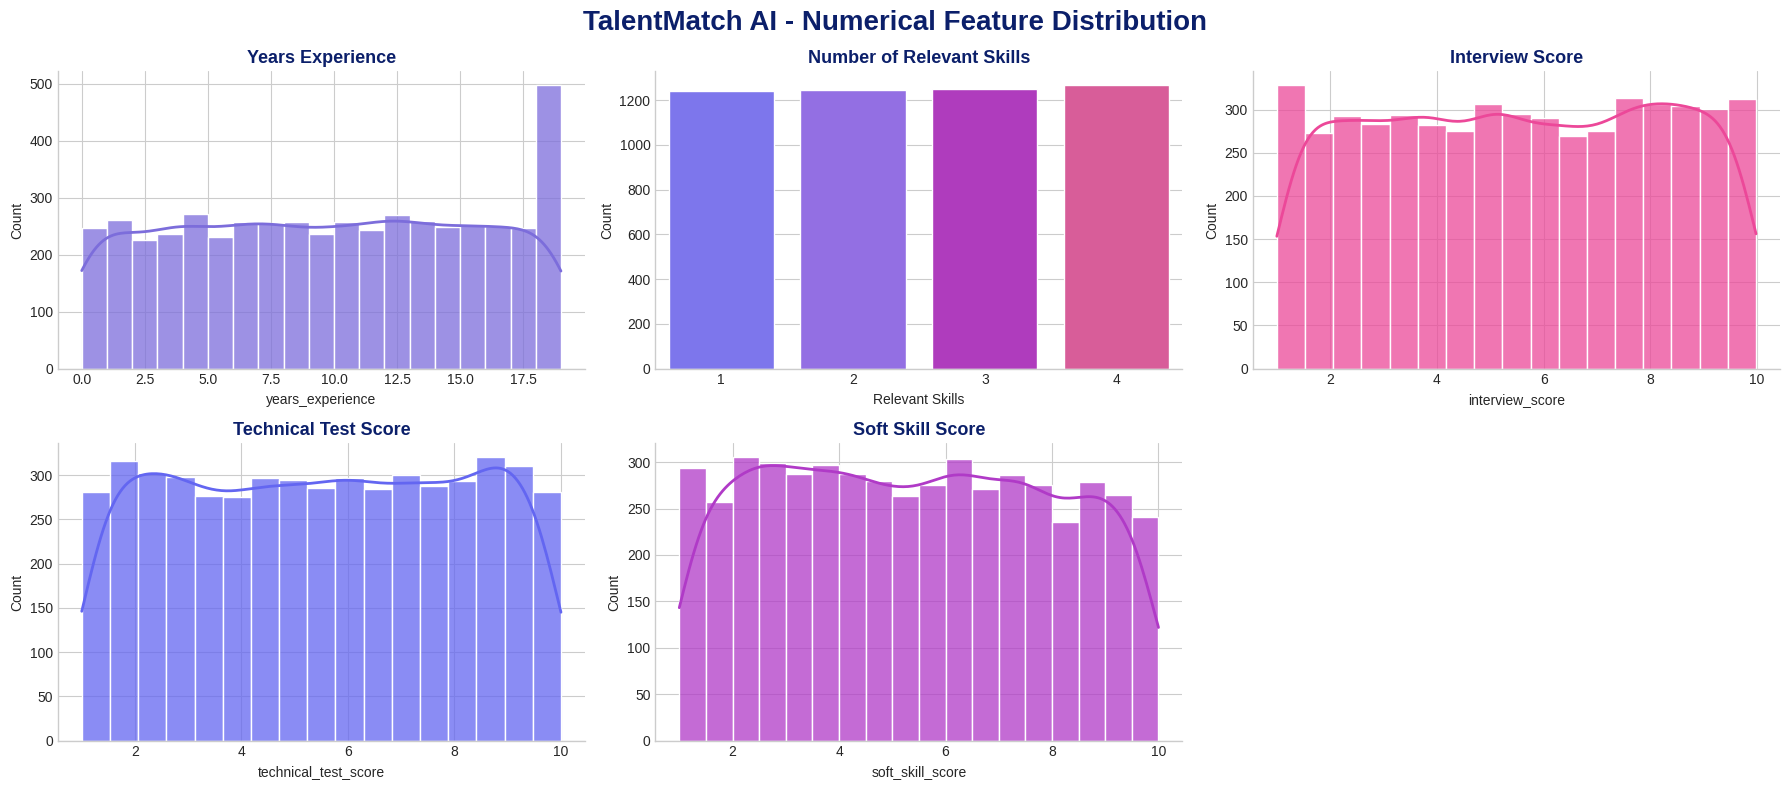

In [ ]:
# Histogram

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(18,8))
axes = axes.flatten()

# Histogram Features
hist_features = [
    'years_experience',
    'interview_score',
    'technical_test_score',
    'soft_skill_score'
]

hist_positions = [0, 2, 3, 4]

colors = [
    '#7C6DDB',
    '#EC4899',
    '#6366F1',
    '#B03AC7'
]

# Histogram
for pos, col, color in zip(hist_positions, hist_features, colors):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color=color,
        alpha=0.75,
        edgecolor='white',
        line_kws={'linewidth':2},
        ax=axes[pos]
    )

    axes[pos].set_title(
        col.replace('_',' ').title(),
        fontsize=13,
        fontweight='bold',
        color='#0B1F6A'
    )

    axes[pos].spines['top'].set_visible(False)
    axes[pos].spines['right'].set_visible(False)

# ======================================================
# Countplot for Number of Relevant Skills
# ======================================================

sns.countplot(
    data=df,
    x='num_relevant_skills',
    palette=['#6C63FF','#8B5CF6','#C026D3','#EC4899'],
    ax=axes[1]
)

axes[1].set_title(
    'Number of Relevant Skills',
    fontsize=13,
    fontweight='bold',
    color='#0B1F6A'
)

axes[1].set_xlabel('Relevant Skills')
axes[1].set_ylabel('Count')

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Remove empty subplot
fig.delaxes(axes[5])

fig.suptitle(
    'TalentMatch AI - Numerical Feature Distribution',
    fontsize=20,
    fontweight='bold',
    color='#0B1F6A'
)

plt.tight_layout()

plt.savefig(
    'Numerical_Feature_Distribution.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

Berdasarkan analisis distribusi fitur numerik, seluruh variabel utama seperti years experience, num relevant skills, interview score, technical test score, dan soft skill score menunjukkan distribusi yang relatif merata tanpa adanya dominasi pada rentang nilai tertentu. Hal ini menunjukkan bahwa dataset mencakup kandidat dengan tingkat pengalaman, keterampilan, dan kompetensi yang beragam.

Selain itu, tidak ditemukan pola distribusi yang ekstrem maupun ketimpangan yang signifikan pada fitur numerik, sehingga kualitas data dinilai cukup baik untuk digunakan dalam proses analisis dan pengembangan model prediksi. Variasi karakteristik kandidat yang luas juga memungkinkan model TalentMatch AI untuk mempelajari berbagai profil kandidat secara lebih objektif dalam menentukan hiring eligibility.


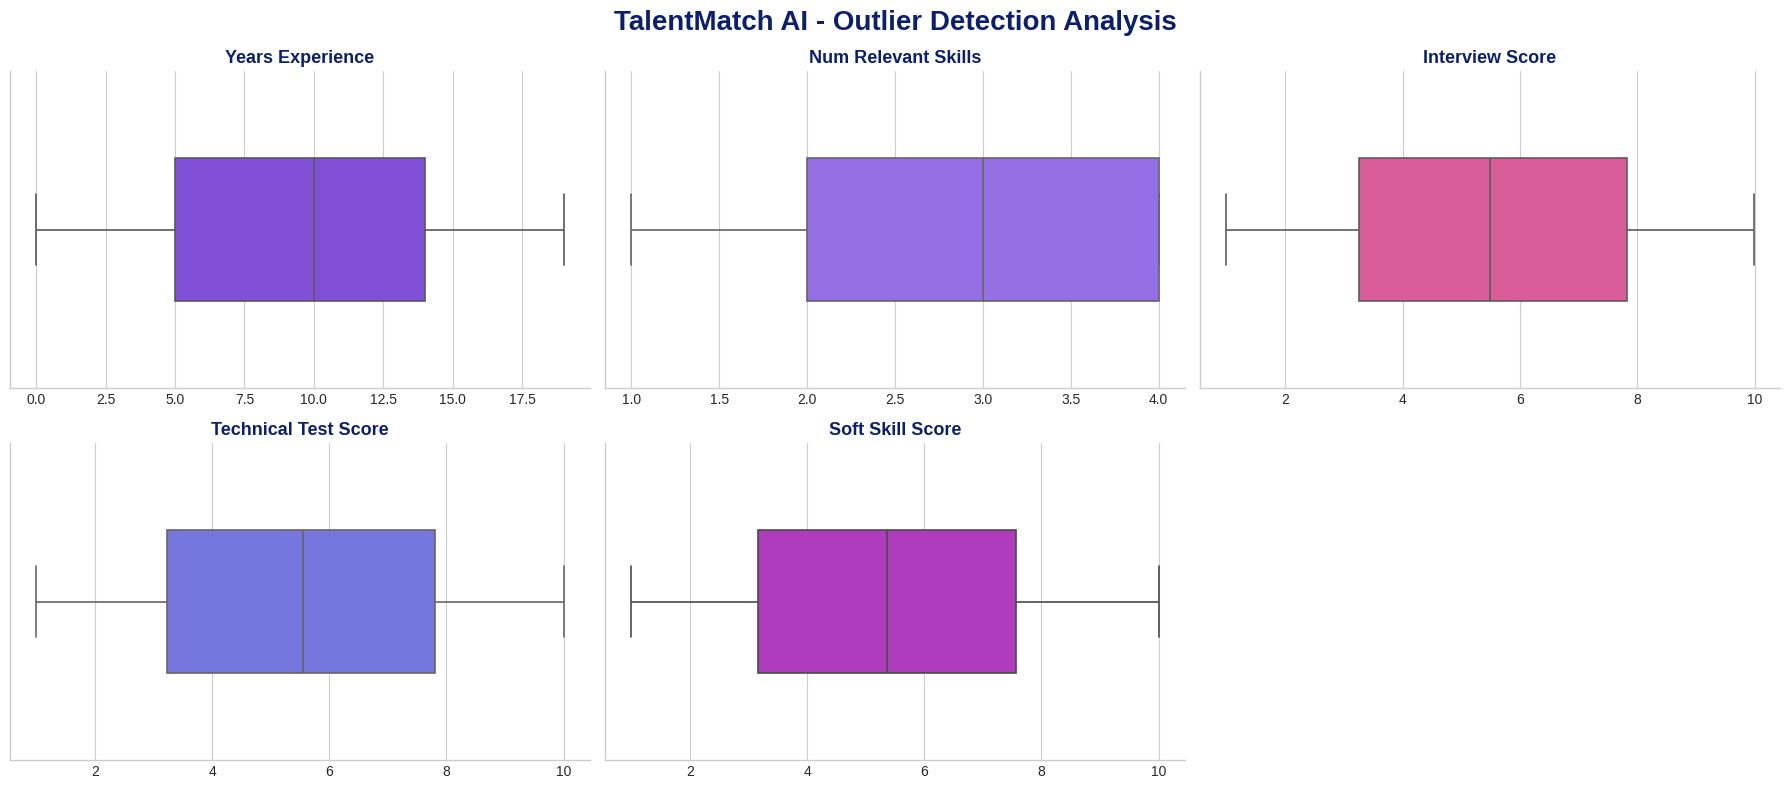

In [ ]:
# Boxplot (Outlier Detection)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical Features
numerical_cols = [
    'years_experience',
    'num_relevant_skills',
    'interview_score',
    'technical_test_score',
    'soft_skill_score'
]

# Style
plt.style.use('seaborn-v0_8-whitegrid')

# Premium Colors (Data Queens Theme)
colors = [
    '#7C3AED',  # Purple
    '#8B5CF6',
    '#EC4899',  # Pink
    '#6366F1',  # Indigo
    '#C026D3'   # Magenta
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,8)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        x=df[col],
        color=colors[i],
        width=0.45,
        linewidth=1.2,
        fliersize=3,
        ax=axes[i]
    )

    axes[i].set_title(
        col.replace('_',' ').title(),
        fontsize=13,
        fontweight='bold',
        color='#0B1F6A'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Hapus subplot kosong
fig.delaxes(axes[5])

fig.suptitle(
    'TalentMatch AI - Outlier Detection Analysis',
    fontsize=20,
    fontweight='bold',
    color='#0B1F6A'
)

plt.tight_layout()

plt.savefig(
    'Outlier_Detection_Analysis.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

Hasil analisis boxplot menunjukkan bahwa seluruh fitur numerik memiliki distribusi yang relatif stabil tanpa adanya outlier yang signifikan. Median pada masing-masing variabel berada di tengah distribusi, menunjukkan sebaran data yang cukup seimbang.

Tidak ditemukannya nilai ekstrem mengindikasikan bahwa kualitas data sudah baik dan tidak memerlukan penanganan khusus terkait outlier pada tahap preprocessing. Kondisi ini mendukung proses analisis dan pengembangan model prediksi karena seluruh kandidat memiliki rentang nilai yang masih representatif terhadap populasi dataset.


In [ ]:
# 2.2 Categorical Features
categorical_cols = [
    'education_level',
    'internal_referral',
    'hiring_eligibility'
]

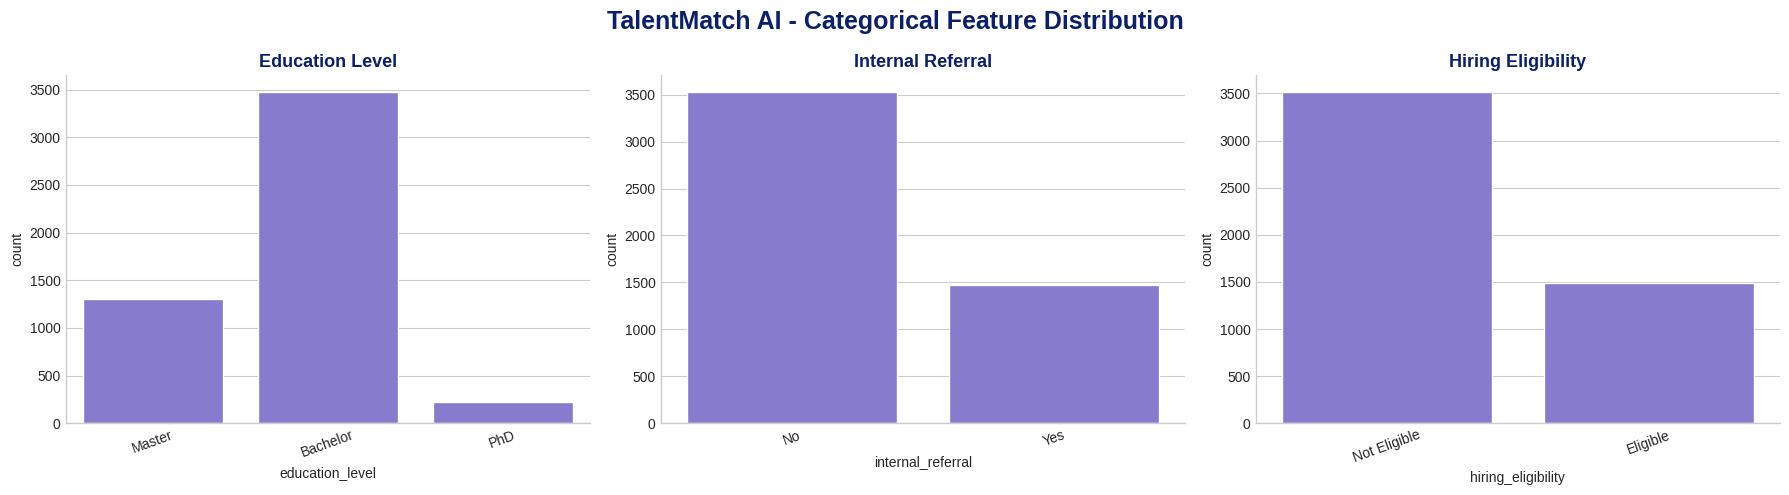

In [ ]:
# 2.3 Countplot
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

for i, col in enumerate(categorical_cols):

    sns.countplot(
        data=df,
        x=col,
        color='#7C6DDB',
        ax=axes[i]
    )

    axes[i].set_title(
        col.replace('_',' ').title(),
        fontsize=13,
        fontweight='bold',
        color='#0B1F6A'
    )

    axes[i].tick_params(axis='x', rotation=20)

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

fig.suptitle(
    'TalentMatch AI - Categorical Feature Distribution',
    fontsize=18,
    fontweight='bold',
    color='#0B1F6A'
)

plt.tight_layout()
plt.show()

Analisis fitur kategorikal menunjukkan bahwa mayoritas kandidat memiliki tingkat pendidikan Bachelor dan berasal dari jalur rekrutmen non-referral. Selain itu, distribusi hiring eligibility didominasi oleh kandidat Not Eligible (70,32%) dibandingkan Eligible (29,68%), yang mengindikasikan adanya ketidakseimbangan kelas (class imbalance) pada dataset. Temuan ini menunjukkan bahwa proses seleksi cukup ketat dan perlu menjadi perhatian pada tahap pengembangan model prediksi agar tidak bias terhadap kelas mayoritas.

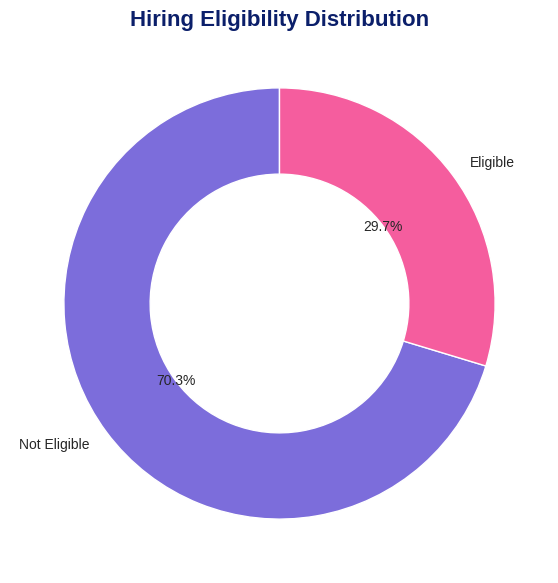

In [ ]:
# 2. 4 Persentase Hiring Eligibility
eligibility = df['hiring_eligibility'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    eligibility,
    labels=eligibility.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#7C6DDB','#F55D9E'],
    wedgeprops=dict(width=0.4)
)

plt.title(
    'Hiring Eligibility Distribution',
    fontsize=16,
    fontweight='bold',
    color='#0B1F6A'
)

plt.show()

**3. MULTIVARIATE ANALYSIS**

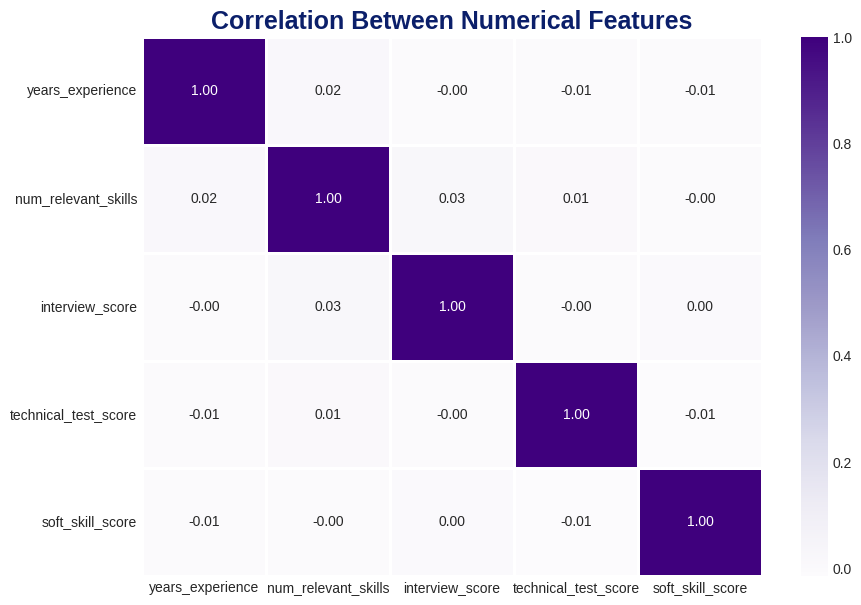

In [ ]:
# 3.1 Correlation Heatmap (untuk melihat hubungan linear antar fitur numerik dan mengidentifikasi apakah terdapat fitur yang saling berkorelasi kuat)
corr_cols = [
    'years_experience',
    'num_relevant_skills',
    'interview_score',
    'technical_test_score',
    'soft_skill_score'
]
corr = df[corr_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='Purples',
    linewidths=1,
    fmt='.2f'
)

plt.title(
    'Correlation Between Numerical Features',
    fontsize=18,
    fontweight='bold',
    color='#0B1F6A'
)

plt.show()

Analisis korelasi menunjukkan bahwa tidak terdapat hubungan linear yang kuat antar fitur numerik. Seluruh variabel memiliki nilai korelasi yang sangat rendah (−0.01 hingga 0.03), sehingga masing-masing fitur memberikan informasi yang unik dalam merepresentasikan karakteristik kandidat. Kondisi ini mengindikasikan tidak adanya masalah multikolinearitas dan mendukung penggunaan seluruh fitur numerik dalam pengembangan model prediksi hiring eligibility.

/tmp/ipykernel_14155/498863121.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_14155/498863121.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_14155/498863121.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_14155/498863121.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


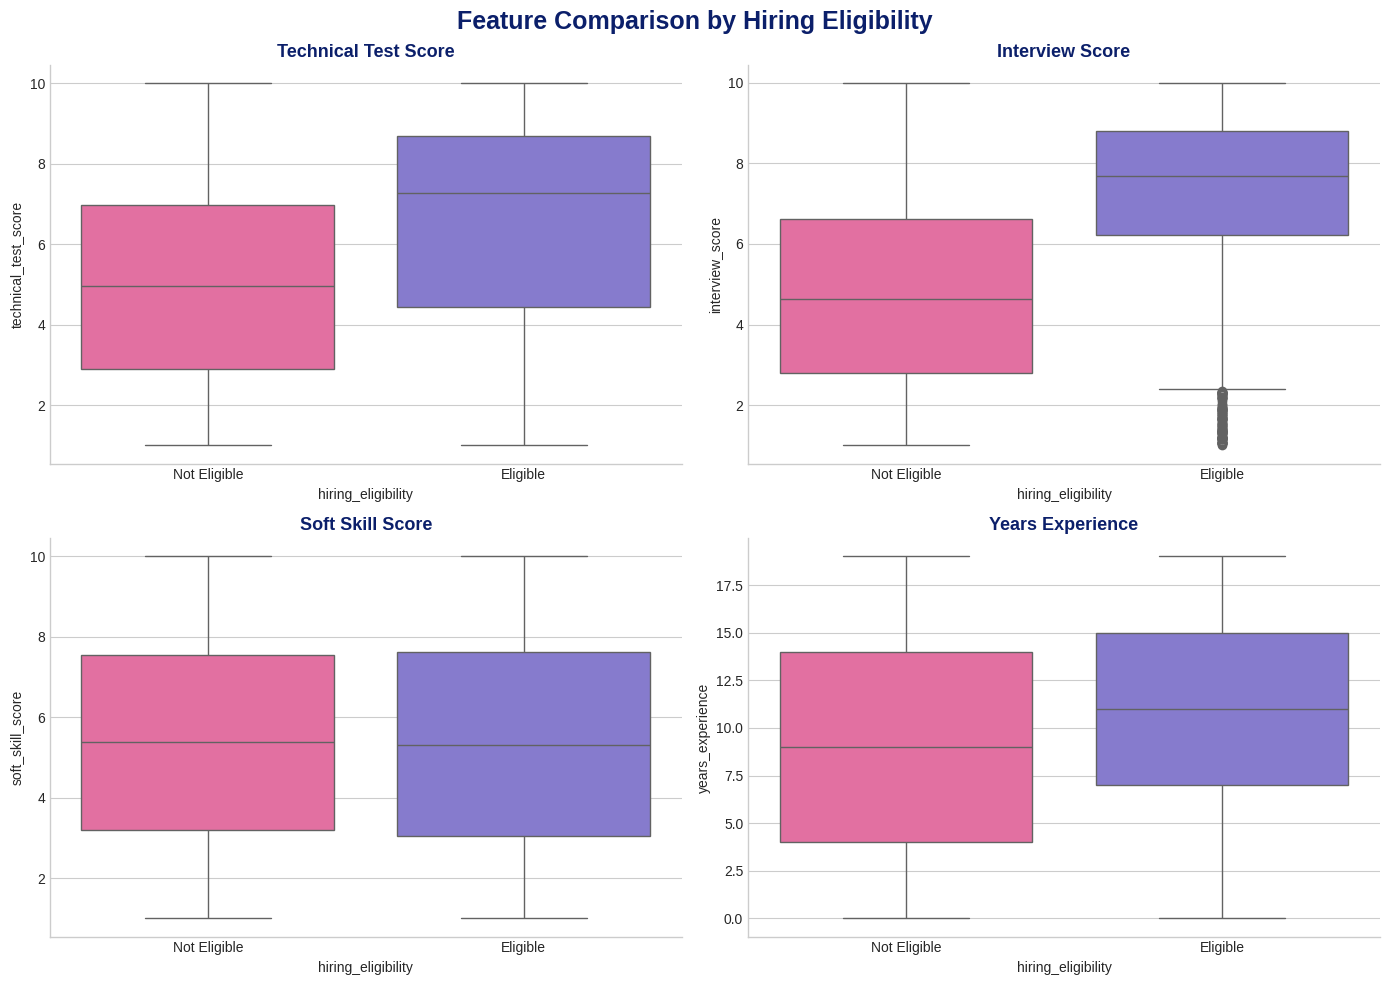

In [ ]:
# 3.2 - 3.5 Feature vs Hiring Eligibility
features = [
    'technical_test_score',
    'interview_score',
    'soft_skill_score',
    'years_experience'
]

titles = [
    'Technical Test Score',
    'Interview Score',
    'Soft Skill Score',
    'Years Experience'
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

axes = axes.flatten()

for i, col in enumerate(features):

    sns.boxplot(
        data=df,
        x='hiring_eligibility',
        y=col,
        palette=['#F55D9E','#7C6DDB'],
        ax=axes[i]
    )

    axes[i].set_title(
        titles[i],
        fontsize=13,
        fontweight='bold',
        color='#0B1F6A'
    )

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

fig.suptitle(
    'Feature Comparison by Hiring Eligibility',
    fontsize=18,
    fontweight='bold',
    color='#0B1F6A'
)

plt.tight_layout()
plt.show()

Analisis perbandingan fitur terhadap hiring eligibility menunjukkan bahwa technical test score dan interview score merupakan faktor yang paling membedakan kandidat Eligible dan Not Eligible. Kandidat yang berhasil memenuhi kriteria seleksi cenderung memiliki skor teknis dan skor wawancara yang lebih tinggi dibandingkan kandidat lainnya.

Sementara itu, years experience menunjukkan pengaruh positif namun relatif lebih kecil, sedangkan soft skill score tidak memperlihatkan perbedaan yang signifikan antar kelompok kandidat. Temuan ini mengindikasikan bahwa kompetensi teknis dan performa wawancara menjadi faktor utama dalam proses evaluasi kandidat pada dataset TalentMatch AI.


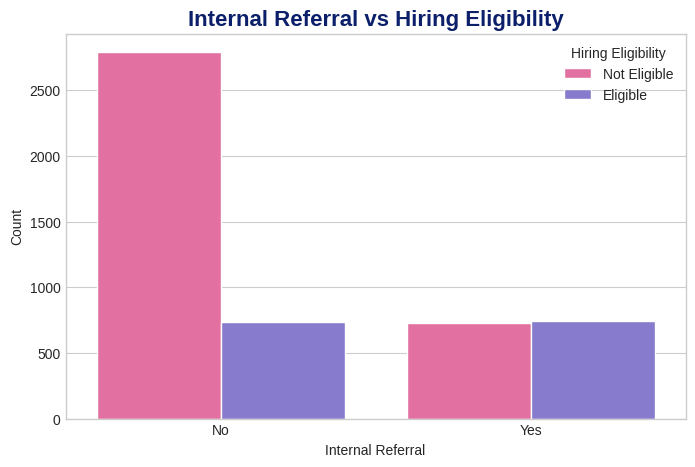

In [ ]:
# 3.6 Internal Referral vs Hiring Eligibility
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='internal_referral',
    hue='hiring_eligibility',
    palette=['#F55D9E','#7C6DDB']
)

plt.title(
    'Internal Referral vs Hiring Eligibility',
    fontsize=16,
    fontweight='bold',
    color='#0B1F6A'
)

plt.xlabel('Internal Referral')
plt.ylabel('Count')

plt.legend(title='Hiring Eligibility')

plt.show()

Kandidat yang berasal dari internal referral menunjukkan peluang kelulusan yang lebih tinggi dibandingkan kandidat non-referral. Hal ini mengindikasikan bahwa program referral dapat menjadi salah satu sumber kandidat berkualitas dalam proses rekrutmen.

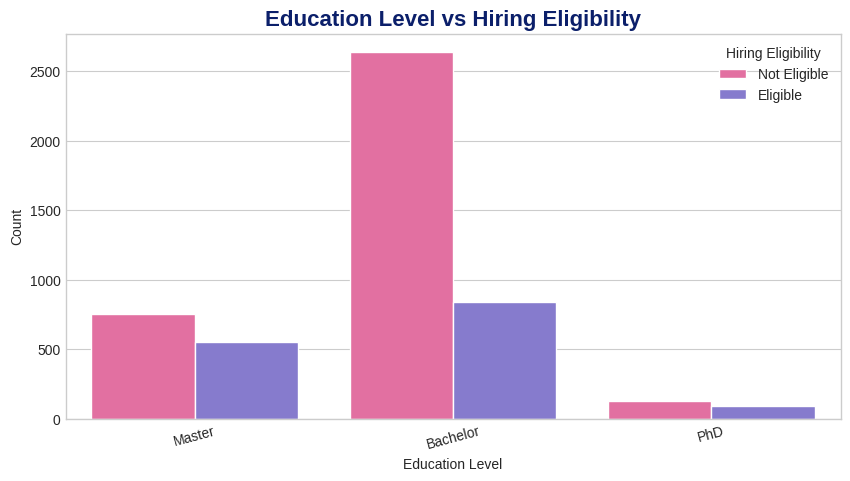

In [ ]:
# 3.7 Education Level vs Hiring Eligibility
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='education_level',
    hue='hiring_eligibility',
    palette=['#F55D9E','#7C6DDB']
)

plt.title(
    'Education Level vs Hiring Eligibility',
    fontsize=16,
    fontweight='bold',
    color='#0B1F6A'
)

plt.xlabel('Education Level')
plt.ylabel('Count')

plt.legend(title='Hiring Eligibility')

plt.xticks(rotation=15)

plt.show()

Kandidat dengan pendidikan Master dan PhD menunjukkan proporsi kelulusan yang lebih tinggi dibandingkan Bachelor. Namun, faktor kompetensi teknis dan hasil wawancara tetap menjadi indikator yang lebih dominan dalam menentukan hiring eligibility.

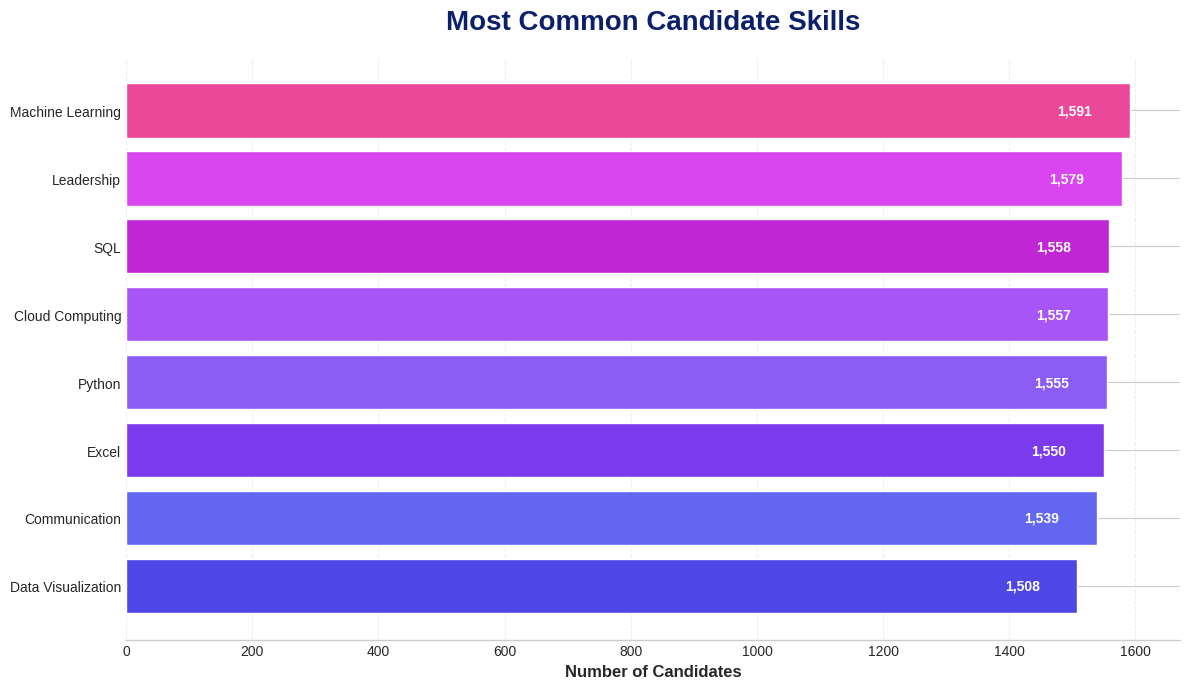

In [ ]:
# Most common candidate skill (skill yang paling banyak dimiliki oleh semua kandidat.)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


# Extract Skills
all_skills = []

for skill_list in df['skills']:
    all_skills.extend(
        [skill.strip() for skill in skill_list.split(',')]
    )

# Count Skills
top_skills = pd.DataFrame(
    Counter(all_skills).most_common(10),
    columns=['Skill','Count']
)

# Sort for Horizontal Chart
top_skills = top_skills.sort_values(
    by='Count',
    ascending=True
)

# Premium Color Palette
colors = [
    '#4F46E5',
    '#6366F1',
    '#7C3AED',
    '#8B5CF6',
    '#A855F7',
    '#C026D3',
    '#D946EF',
    '#EC4899',
    '#F472B6',
    '#F55D9E'
]

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12,7))

bars = ax.barh(
    top_skills['Skill'],
    top_skills['Count'],
    color=colors
)

# Value Labels
for bar in bars:

    width = bar.get_width()

    ax.text(
        width - 60,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        ha='right',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

# Title
ax.set_title(
    'Most Common Candidate Skills',
    fontsize=20,
    fontweight='bold',
    color='#0B1F6A',
    pad=20
)

ax.set_xlabel(
    'Number of Candidates',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel('')

# Clean Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

# Save PNG
plt.savefig(
    'Most_Common_Candidate_Skills.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

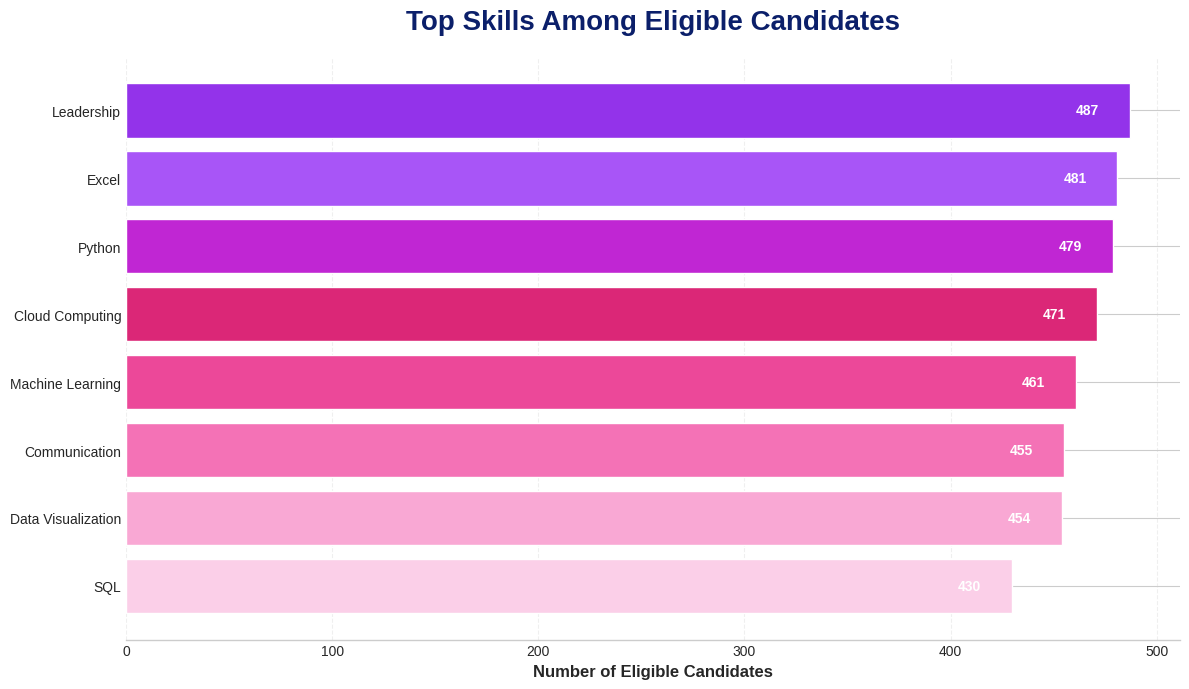

In [ ]:
# Skills vs Hiring Eligibility (skill kandidat yg memenuhi kriteria)
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Filter for eligible candidates
eligible_df = df[df['hiring_eligibility'] == 'Eligible']

# Extract skills from eligible candidates
all_eligible_skills = []
for skill_list in eligible_df['skills']:
    all_eligible_skills.extend(
        [skill.strip() for skill in skill_list.split(',')]
    )

# Count skills and get top 10
top_eligible_skills = pd.DataFrame(
    Counter(all_eligible_skills).most_common(10),
    columns=['Skill','Count']
)

# Sort ascending untuk horizontal chart
top_eligible_skills = top_eligible_skills.sort_values(
    by='Count',
    ascending=True
)

# Premium Pink-Purple Palette
colors = [
    '#FBCFE8',
    '#F9A8D4',
    '#F472B6',
    '#EC4899',
    '#DB2777',
    '#C026D3',
    '#A855F7',
    '#9333EA',
    '#7C3AED',
    '#6D28D9'
]

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12,7))

bars = ax.barh(
    top_eligible_skills['Skill'],
    top_eligible_skills['Count'],
    color=colors
)

# Value Label
for bar in bars:

    width = bar.get_width()

    ax.text(
        width - 15,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        ha='right',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

# Title
ax.set_title(
    'Top Skills Among Eligible Candidates',
    fontsize=20,
    fontweight='bold',
    color='#0B1F6A',
    pad=20
)

ax.set_xlabel(
    'Number of Eligible Candidates',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel('')

# Clean Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

# Save PNG
plt.savefig(
    'Top_Eligible_Skills_Executive.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

In [ ]:
df.info()
df.describe()
df['hiring_eligibility'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   candidate_id          5000 non-null   int64  
 1   job_id                5000 non-null   int64  
 2   education_level       5000 non-null   object 
 3   years_experience      5000 non-null   int64  
 4   num_relevant_skills   5000 non-null   int64  
 5   skills                5000 non-null   object 
 6   internal_referral     5000 non-null   object 
 7   interview_score       5000 non-null   float64
 8   technical_test_score  5000 non-null   float64
 9   soft_skill_score      5000 non-null   float64
 10  hiring_eligibility    5000 non-null   object 
dtypes: float64(3), int64(4), object(4)
memory usage: 429.8+ KB


,count
hiring_eligibility,
Not Eligible,3516
Eligible,1484


In [ ]:
# CELL 1 T-Test & Chi-Square

import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency

# Membagi data berdasarkan target
eligible = df[df["hiring_eligibility"] == "Eligible"]
not_eligible = df[df["hiring_eligibility"] == "Not Eligible"]

# ===========================
# Independent T-Test
# ===========================
numerical_cols = [
    "years_experience",
    "num_relevant_skills",
    "interview_score",
    "technical_test_score",
    "soft_skill_score"
]

print("===== T-Test Result =====")

for col in numerical_cols:
    t_stat, p_value = ttest_ind(
        eligible[col],
        not_eligible[col],
        equal_var=False
    )

    print(f"{col}")
    print(f"T-statistic : {t_stat:.3f}")
    print(f"P-value     : {p_value:.5e}")

    if p_value < 0.05:
        print("Conclusion  : Significant\n")
    else:
        print("Conclusion  : Not Significant\n")

# ===========================
# Chi-Square Test
# ===========================

categorical_cols = [
    "education_level",
    "internal_referral"
]

print("===== Chi-Square Result =====")

for col in categorical_cols:

    contingency = pd.crosstab(
        df[col],
        df["hiring_eligibility"]
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    print(col)
    print(f"Chi2      : {chi2:.3f}")
    print(f"P-value   : {p_value:.5e}")

    if p_value < 0.05:
        print("Conclusion: Significant\n")
    else:
        print("Conclusion: Not Significant\n")

===== T-Test Result =====
years_experience
T-statistic : 9.378
P-value     : 1.25546e-20
Conclusion  : Significant

num_relevant_skills
T-statistic : 16.051
P-value     : 1.20631e-55
Conclusion  : Significant

interview_score
T-statistic : 31.286
P-value     : 3.25952e-186
Conclusion  : Significant

technical_test_score
T-statistic : 17.580
P-value     : 1.31423e-65
Conclusion  : Significant

soft_skill_score
T-statistic : -0.568
P-value     : 5.69910e-01
Conclusion  : Not Significant

===== Chi-Square Result =====
education_level
Chi2      : 166.165
P-value   : 8.27314e-37
Conclusion: Significant

internal_referral
Chi2      : 440.371
P-value   : 8.98760e-98
Conclusion: Significant



In [ ]:
import pandas as pd
from itertools import combinations

# Define the list of skill column names that will be generated.
# These are derived from `skill_df.columns` clean-up and used for combinations.
expected_ohe_skill_columns = [
    "cloud_computing",
    "communication",
    "data_visualization",
    "excel",
    "leadership",
    "machine_learning",
    "python",
    "sql"
]

# Identify and drop any existing skill columns from df to prevent duplicates
# if this cell is executed multiple times without restarting the kernel.
columns_to_drop = [col for col in expected_ohe_skill_columns if col in df.columns]
if columns_to_drop:
    df = df.drop(columns=columns_to_drop)

# =====================================================
# One-Hot Encoding Skills
# =====================================================
skill_df = df["skills"].str.get_dummies(sep=", ")

# Rapikan nama kolom
skill_df.columns = (
    skill_df.columns
            .str.lower()
            .str.replace(" ", "_", regex=False)
)

# Gabungkan ke dataset
df = pd.concat([df, skill_df], axis=1)

# =====================================================
# 8 Skill Utama
# =====================================================
top_skills = [
    "machine_learning",
    "leadership",
    "sql",
    "cloud_computing",
    "python",
    "excel",
    "communication",
    "data_visualization"
]

# =====================================================
# Hitung Seluruh Kombinasi (8C2 = 28)
# =====================================================
results = []

for skill1, skill2 in combinations(top_skills, 2):

    subset = df[
        (df[skill1] == 1) &
        (df[skill2] == 1)
    ]

    total = len(subset)

    if total == 0:
        eligible_rate = 0
    else:
        eligible = subset["hiring_eligibility"].eq("Eligible").sum()
        eligible_rate = (eligible / total) * 100

    results.append({
        "Combination":
            f"{skill1.replace('_',' ').title()} + {skill2.replace('_',' ').title()}",
        "Eligible Rate":
            f"{eligible_rate:.2f}%"
    })

# =====================================================
# DataFrame Hasil
# =====================================================
result = (
    pd.DataFrame(results)
    .sort_values("Combination")
    .reset_index(drop=True)
)

print(f"Total Kombinasi : {len(result)}")
print(result.to_string(index=False))

Total Kombinasi : 28
                          Combination Eligible Rate
      Cloud Computing + Communication        31.26%
 Cloud Computing + Data Visualization        30.66%
              Cloud Computing + Excel        31.73%
             Cloud Computing + Python        29.91%
   Communication + Data Visualization        31.86%
                Excel + Communication        30.62%
           Excel + Data Visualization        33.33%
         Leadership + Cloud Computing        33.81%
           Leadership + Communication        30.61%
      Leadership + Data Visualization        31.15%
                   Leadership + Excel        32.60%
                  Leadership + Python        32.91%
                     Leadership + Sql        27.85%
   Machine Learning + Cloud Computing        28.21%
     Machine Learning + Communication        30.49%
Machine Learning + Data Visualization        29.48%
             Machine Learning + Excel        32.78%
        Machine Learning + Leadership      

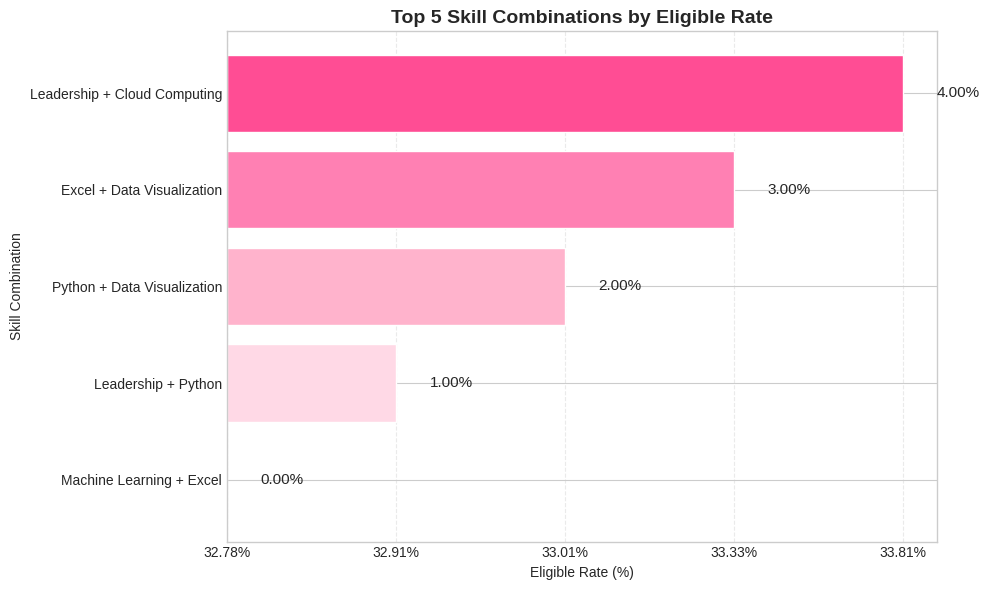

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil Top 5 berdasarkan Eligible Rate
top5 = result.sort_values(by='Eligible Rate', ascending=False).head(5)

# Warna gradasi pink -> putih
colors = ['#ff4d94', '#ff80b3', '#ffb3cc', '#ffd9e6', '#ffffff']

plt.figure(figsize=(10,6))

bars = plt.barh(
    top5['Combination'][::-1],
    top5['Eligible Rate'][::-1],
    color=colors[::-1]
)

# Tambahkan label persentase
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}%',
        va='center',
        fontsize=11
    )

plt.title('Top 5 Skill Combinations by Eligible Rate', fontsize=14, fontweight='bold')
plt.xlabel('Eligible Rate (%)')
plt.ylabel('Skill Combination')

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

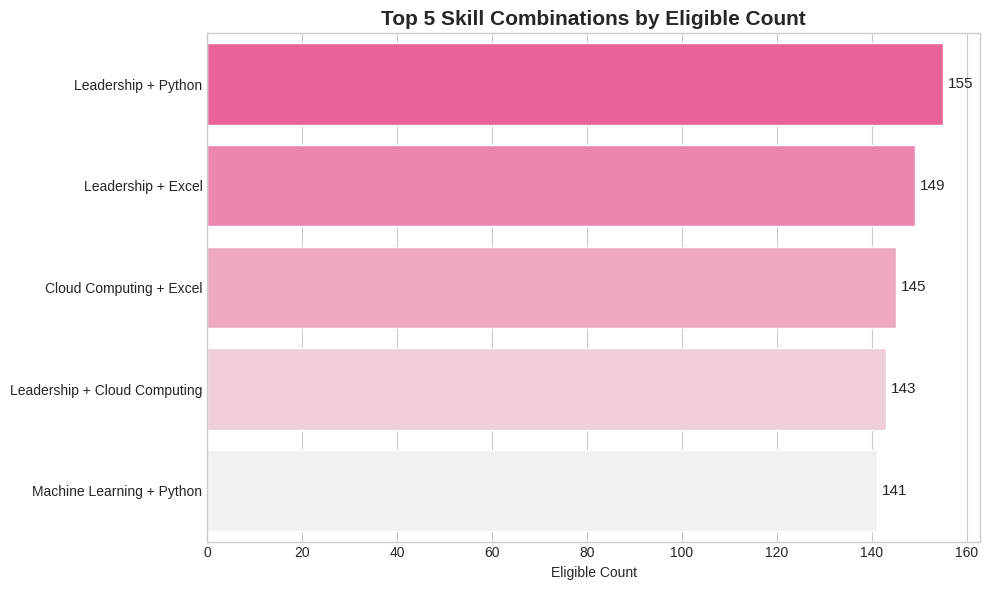

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from itertools import combinations

# Regenerate the result DataFrame to ensure 'Eligible Candidate' column is present
# This logic is adapted from cell kC4oh3tBjB0Q

# The one-hot encoding of skills and concatenation to df is already done in a previous cell (iccf89x0-sCG).
# Running it again would create duplicate columns and cause an error.
# Therefore, we will skip this part.

# Top 8 Skills
top_skills = [
    "machine_learning",
    "leadership",
    "sql",
    "cloud_computing",
    "python",
    "excel",
    "communication",
    "data_visualization"
]

results = []

# 28 Combination
for skill1, skill2 in combinations(top_skills,2):
    subset = df[
        (df[skill1]==1) &
        (df[skill2]==1)
    ]
    total = len(subset)
    eligible = subset["hiring_eligibility"].eq("Eligible").sum()
    eligible_rate = (
        eligible/total*100
        if total>0 else 0
    )
    results.append({
        "Combination":
        f"{skill1.replace('_',' ').title()} + {skill2.replace('_',' ').title()}",
        "Eligible Candidate":
eligible,
        "Total Candidate":
total,
        "Eligible Rate":
        round(eligible_rate,2)
    })

result = pd.DataFrame(results)
result = result.sort_values(
    by="Eligible Rate",
    ascending=False
)
result["Eligible Rate"] = (
    result["Eligible Rate"]
    .astype(str)+"%"
)

# Ambil Top 5 berdasarkan Eligible Candidate
top5 = result.sort_values(by='Eligible Candidate', ascending=False).head(5)

# Gradasi pink -> putih
palette = sns.light_palette("#ff4d94", n_colors=5, reverse=True)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top5,
    y='Combination',
    x='Eligible Candidate',
    palette=palette,
    hue='Combination', # Explicitly assign y variable to hue
    legend=False        # Set legend to False as per warning
)

# Label count
for i, v in enumerate(top5['Eligible Candidate']):
    ax.text(v + 1, i, str(v), va='center', fontsize=11)

plt.title('Top 5 Skill Combinations by Eligible Count', fontsize=15, fontweight='bold')
plt.xlabel('Eligible Count')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from itertools import combinations
from scipy.stats import chi2_contingency

# ======================================================
# 8 Skill Utama
# ======================================================
top_skills = [
    "machine_learning",
    "leadership",
    "sql",
    "cloud_computing",
    "python",
    "excel",
    "communication",
    "data_visualization"
]

results = []

# ======================================================
# Analisis 28 Kombinasi Skill
# ======================================================
for skill1, skill2 in combinations(top_skills, 2):

    # Kandidat memiliki kedua skill
    combo_feature = (
        (df[skill1] == 1) &
        (df[skill2] == 1)
    ).astype(int)

    # =========================
    # Eligible Rate
    # =========================
    total = combo_feature.sum()

    if total == 0:
        eligible_rate = 0
    else:
        eligible = df.loc[
            combo_feature == 1,
            "hiring_eligibility"
        ].eq("Eligible").sum()

        eligible_rate = eligible / total * 100

    # =========================
    # Chi Square Test
    # =========================
    contingency = pd.crosstab(
        combo_feature,
        df["hiring_eligibility"]
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    results.append({
        "Combination":
            f"{skill1.replace('_',' ').title()} + {skill2.replace('_',' ').title()}",
        "Eligible Rate":
            round(eligible_rate,2),
        "Chi2":
            round(chi2,3),
        "P-value":
            p,
        "Conclusion":
            "Significant" if p < 0.05 else "Not Significant"
    })

# ======================================================
# Hasil
# ======================================================
result = pd.DataFrame(results)

result = result.sort_values(
    by=["Chi2","Eligible Rate"],
    ascending=False
).reset_index(drop=True)

# Format tampilan
result["Eligible Rate"] = result["Eligible Rate"].astype(str) + "%"

result["P-value"] = result["P-value"].apply(
    lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"
)

print(result)

                              Combination Eligible Rate   Chi2 P-value  \
0            Leadership + Cloud Computing        33.81%  3.557   0.059   
1              Excel + Data Visualization        33.33%  2.767   0.096   
2                     Leadership + Python        32.91%  2.429   0.119   
3             Python + Data Visualization        33.01%  2.237   0.135   
4                     Sql + Communication        26.42%  2.198   0.138   
5                Machine Learning + Excel        32.78%  1.978   0.160   
6                      Leadership + Excel         32.6%  1.909   0.167   
7                  Python + Communication        26.94%  1.473   0.225   
8                Sql + Data Visualization        26.99%  1.434   0.231   
9           Machine Learning + Leadership        27.23%  1.361   0.243   
10     Communication + Data Visualization        31.86%  0.960   0.327   
11                 Machine Learning + Sql        27.52%  0.955   0.329   
12                Cloud Computing + Ex

In [ ]:
import pandas as pd
from itertools import combinations

# ==========================
# One Hot Encoding Skills
# ==========================
# This operation is already performed in cell iccf89x0-sCG.
# Running it again would create duplicate columns.
# skill_df = df["skills"].str.get_dummies(sep=", ")

# skill_df.columns = (
#     skill_df.columns
#             .str.lower()
#             .str.replace(" ", "_", regex=False)
# )

# df = pd.concat([df, skill_df], axis=1)

# ==========================
# Top 8 Skills
# ==========================
top_skills = [
    "machine_learning",
    "leadership",
    "sql",
    "cloud_computing",
    "python",
    "excel",
    "communication",
    "data_visualization"
]

results = []

# ==========================
# 28 Combination
# ==========================
for skill1, skill2 in combinations(top_skills,2):

    subset = df[
        (df[skill1]==1) &
        (df[skill2]==1)
    ]

    total = len(subset)

    eligible = subset["hiring_eligibility"].eq("Eligible").sum()

    eligible_rate = (
        eligible/total*100
        if total>0 else 0
    )

    results.append({

        "Combination":
        f"{skill1.replace('_',' ').title()} + {skill2.replace('_',' ').title()}",

        "Eligible Candidate":
eligible,

        "Total Candidate":
total,

        "Eligible Rate":
        round(eligible_rate,2)

    })

result = pd.DataFrame(results)

result = result.sort_values(
    by="Eligible Rate",
    ascending=False
)

result["Eligible Rate"] = (
    result["Eligible Rate"]
    .astype(str)+"%"
)

print(result)

                              Combination  Eligible Candidate  \
8            Leadership + Cloud Computing                 143   
26             Excel + Data Visualization                 141   
24            Python + Data Visualization                 137   
9                     Leadership + Python                 155   
4                Machine Learning + Excel                 139   
10                     Leadership + Excel                 149   
27     Communication + Data Visualization                 137   
19                Cloud Computing + Excel                 145   
20        Cloud Computing + Communication                 136   
3               Machine Learning + Python                 141   
12        Leadership + Data Visualization                 138   
21   Cloud Computing + Data Visualization                 134   
13                  Sql + Cloud Computing                 140   
25                  Excel + Communication                 139   
11             Leadership

In [ ]:
top3 = result.head(3)

print(top3.to_string(index=False))

                 Combination  Eligible Candidate  Total Candidate Eligible Rate
Leadership + Cloud Computing                 143              423        33.81%
  Excel + Data Visualization                 141              423        33.33%
 Python + Data Visualization                 137              415        33.01%


In [ ]:
print("===== Business Insight =====\n")

print(
"""
Top 3 skill combinations with the highest Eligible Rate are:

1. Leadership + Cloud Computing
2. Excel + Data Visualization
3. Python + Data Visualization

These combinations have a higher proportion of Eligible candidates
compared to other combinations and can be considered as supporting
indicators in the candidate screening process.

However, based on previous statistical analysis, Interview Score,
Technical Test Score, Years Experience, Education Level,
and Internal Referral remain the primary factors significantly
associated with Hiring Eligibility.
"""
)

===== Business Insight =====


Top 3 skill combinations with the highest Eligible Rate are:

1. Leadership + Cloud Computing
2. Excel + Data Visualization
3. Python + Data Visualization

These combinations have a higher proportion of Eligible candidates
compared to other combinations and can be considered as supporting
indicators in the candidate screening process.

However, based on previous statistical analysis, Interview Score,
Technical Test Score, Years Experience, Education Level,
and Internal Referral remain the primary factors significantly
associated with Hiring Eligibility.



Berdasarkan analisis kombinasi, kami menggunakan Eligible Rate untuk mengidentifikasi kombinasi skill yang paling potensial sebagai business insight. Sementara itu, hubungan statistik terhadap Hiring Eligibility telah divalidasi melalui T-Test dan Chi-Square pada fitur utama, yang menunjukkan bahwa Interview Score, Technical Test Score, Years Experience, Education Level, dan Internal Referral merupakan faktor yang signifikan."

Menurut saya, ini adalah solusi paling aman, konsisten, dan mudah dipertanggungjawabkan untuk presentasi besok.

#**Feature Selection & Engineering**

In [ ]:
# Fitur seleksi

# Copy DataFrame
df_model = df.copy()

# Hapus kolom kandidat id dan job id
df_drop = df_model.drop(columns=['candidate_id', 'job_id'])
df_drop.head()

,education_level,years_experience,num_relevant_skills,skills,internal_referral,interview_score,technical_test_score,soft_skill_score,hiring_eligibility,cloud_computing,communication,data_visualization,excel,leadership,machine_learning,python,sql
0,Master,17,2,"Cloud Computing, Python",No,1.47,5.53,7.30,Not Eligible,1,0,0,0,0,0,1,0
1,Bachelor,19,3,"Leadership, Machine Learning",No,8.46,7.27,7.57,Eligible,0,0,0,0,1,1,0,0
2,Bachelor,6,3,"Python, SQL, Data Visualization",Yes,8.62,6.88,5.47,Eligible,0,0,1,0,0,0,1,1
3,Master,1,4,"SQL, Data Visualization",No,7.78,1.07,8.54,Not Eligible,0,0,1,0,0,0,0,1
4,Bachelor,9,3,"Excel, Communication, Python",Yes,7.94,1.75,4.33,Eligible,0,1,0,1,0,0,1,0


Fitur yang diseleksi adalah candidate id dan job id karena tidak berpengaruh terhadap model. Data tanpa kedua fitur tersebut didefinisikan sebagai df_drop.

In [ ]:
# A. Encoding Ordinal untuk Education Level
mapping_education = {'Bachelor': 0, 'Master': 1, 'PhD': 2}
df_drop['education_level'] = df_drop['education_level'].map(mapping_education)
df_drop.head()

,education_level,years_experience,num_relevant_skills,skills,internal_referral,interview_score,technical_test_score,soft_skill_score,hiring_eligibility,cloud_computing,communication,data_visualization,excel,leadership,machine_learning,python,sql
0,1,17,2,"Cloud Computing, Python",No,1.47,5.53,7.30,Not Eligible,1,0,0,0,0,0,1,0
1,0,19,3,"Leadership, Machine Learning",No,8.46,7.27,7.57,Eligible,0,0,0,0,1,1,0,0
2,0,6,3,"Python, SQL, Data Visualization",Yes,8.62,6.88,5.47,Eligible,0,0,1,0,0,0,1,1
3,1,1,4,"SQL, Data Visualization",No,7.78,1.07,8.54,Not Eligible,0,0,1,0,0,0,0,1
4,0,9,3,"Excel, Communication, Python",Yes,7.94,1.75,4.33,Eligible,0,1,0,1,0,0,1,0


In [ ]:
# B. Encoding Biner untuk Internal Referral & Target Variable
df_drop['internal_referral'] = df_drop['internal_referral'].map({'No': 0, 'Yes': 1})
df_drop['hiring_eligibility'] = df_drop['hiring_eligibility'].map({'Not Eligible': 0, 'Eligible': 1})

In [ ]:
df_drop.head()

,education_level,years_experience,num_relevant_skills,skills,internal_referral,interview_score,technical_test_score,soft_skill_score,hiring_eligibility,cloud_computing,communication,data_visualization,excel,leadership,machine_learning,python,sql
0,1,17,2,"Cloud Computing, Python",0,1.47,5.53,7.30,0,1,0,0,0,0,0,1,0
1,0,19,3,"Leadership, Machine Learning",0,8.46,7.27,7.57,1,0,0,0,0,1,1,0,0
2,0,6,3,"Python, SQL, Data Visualization",1,8.62,6.88,5.47,1,0,0,1,0,0,0,1,1
3,1,1,4,"SQL, Data Visualization",0,7.78,1.07,8.54,0,0,0,1,0,0,0,0,1
4,0,9,3,"Excel, Communication, Python",1,7.94,1.75,4.33,1,0,1,0,1,0,0,1,0


In [ ]:
# C. Feature Extraction dari Kolom 'skills' (Contoh menggunakan str.contains)
# Memisahkan skill populer menjadi kolom biner tersedianya masing-masing
top_skills = ['Machine Learning', 'Leadership', 'SQL', 'Cloud Computing', 'Python', 'Excel', 'Communication', 'Data Visualization']

for skill in top_skills:
    df_drop[f'skill_{skill.lower().replace(" ", "_")}'] = (
        df_drop['skills'].str.contains(skill, case=False, na=False).astype(int)
    )

In [ ]:
df_drop.head()

,education_level,years_experience,num_relevant_skills,skills,internal_referral,interview_score,technical_test_score,soft_skill_score,hiring_eligibility,cloud_computing,...,python,sql,skill_machine_learning,skill_leadership,skill_sql,skill_cloud_computing,skill_python,skill_excel,skill_communication,skill_data_visualization
0,1,17,2,"Cloud Computing, Python",0,1.47,5.53,7.30,0,1,...,1,0,0,0,0,1,1,0,0,0
1,0,19,3,"Leadership, Machine Learning",0,8.46,7.27,7.57,1,0,...,0,0,1,1,0,0,0,0,0,0
2,0,6,3,"Python, SQL, Data Visualization",1,8.62,6.88,5.47,1,0,...,1,1,0,0,1,0,1,0,0,1
3,1,1,4,"SQL, Data Visualization",0,7.78,1.07,8.54,0,0,...,0,1,0,0,1,0,0,0,0,1
4,0,9,3,"Excel, Communication, Python",1,7.94,1.75,4.33,1,0,...,1,0,0,0,0,0,1,1,1,0


Feature extraction dilakukan terhadap 8 skill dengan frekuensi kemunculan tertinggi pada dataset, yaitu Machine Learning, Leadership, SQL, Cloud Computing, Python, Excel, Communication, dan Data Visualization.

In [ ]:
from itertools import combinations

# Daftar skill yang sudah diekstraksi
skill_columns = [
    'skill_cloud_computing',
    'skill_communication',
    'skill_data_visualization',
    'skill_excel',
    'skill_leadership',
    'skill_machine_learning',
    'skill_python',
    'skill_sql'
]

# Membuat semua kombinasi 2 skill
for skill1, skill2 in combinations(skill_columns, 2):

    # Nama kolom baru
    new_col = f"{skill1}_{skill2}"

    # AND (keduanya harus dimiliki)
    df_drop[new_col] = (
        (df_drop[skill1] == 1) &
        (df_drop[skill2] == 1)
    ).astype(int)

print("Total fitur baru:", len(list(combinations(skill_columns, 2))))

Total fitur baru: 28


In [ ]:
# Hapus kolom 'skills' asli dari df_model
df_drop = df_drop.drop(columns=['skills'])

# Cek kembali hasilnya
df_drop.head()

,education_level,years_experience,num_relevant_skills,internal_referral,interview_score,technical_test_score,soft_skill_score,hiring_eligibility,cloud_computing,communication,...,skill_excel_skill_leadership,skill_excel_skill_machine_learning,skill_excel_skill_python,skill_excel_skill_sql,skill_leadership_skill_machine_learning,skill_leadership_skill_python,skill_leadership_skill_sql,skill_machine_learning_skill_python,skill_machine_learning_skill_sql,skill_python_skill_sql
0,1,17,2,0,1.47,5.53,7.30,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,19,3,0,8.46,7.27,7.57,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,6,3,1,8.62,6.88,5.47,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,1,4,0,7.78,1.07,8.54,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,9,3,1,7.94,1.75,4.33,1,0,1,...,0,0,1,0,0,0,0,0,0,0


--- URUTAN FAKTOR YANG PALING MEMENGARUHI ELIGIBILITY ---
1. interview_score           : Kekuatan Pengaruh = 0.3940 (Positif (+))
2. internal_referral         : Kekuatan Pengaruh = 0.2973 (Positif (+))
3. technical_test_score      : Kekuatan Pengaruh = 0.2440 (Positif (+))
4. num_relevant_skills       : Kekuatan Pengaruh = 0.2165 (Positif (+))
5. education_level           : Kekuatan Pengaruh = 0.1716 (Positif (+))
6. years_experience          : Kekuatan Pengaruh = 0.1255 (Positif (+))
7. sql                       : Kekuatan Pengaruh = 0.0306 (Negatif (-))
8. skill_sql                 : Kekuatan Pengaruh = 0.0306 (Negatif (-))
9. skill_cloud_computing_skill_leadership : Kekuatan Pengaruh = 0.0275 (Positif (+))
10. skill_data_visualization_skill_excel : Kekuatan Pengaruh = 0.0243 (Positif (+))
11. skill_leadership_skill_python : Kekuatan Pengaruh = 0.0228 (Positif (+))
12. skill_data_visualization_skill_python : Kekuatan Pengaruh = 0.0219 (Positif (+))
13. skill_communication_skill_sql :

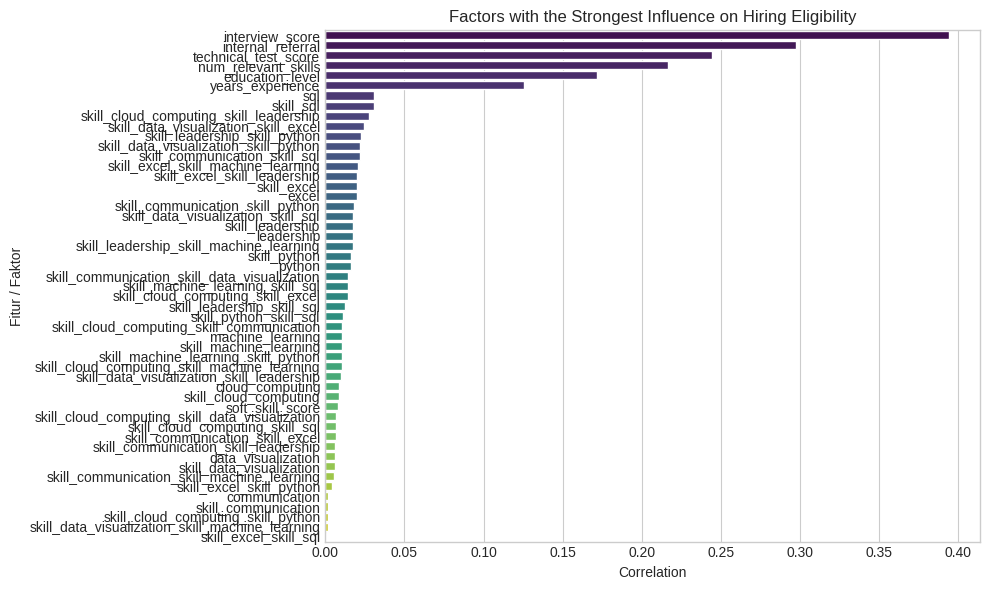

In [ ]:
# Mengurutkan faktor yang berpengaruh terhadap Eligibility

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung Korelasi Terhadap Target 'hiring_eligibility'
korelasi_target = df_drop.corr()['hiring_eligibility'].drop('hiring_eligibility')

# Ubah ke nilai mutlak (absolute) untuk melihat kekuatan hubungan, lalu urutkan dari tertinggi
faktor_pengaruh = korelasi_target.abs().sort_values(ascending=False)

# Tampilkan Hasil Urutan Faktor Pengaruh
print("--- URUTAN FAKTOR YANG PALING MEMENGARUHI ELIGIBILITY ---")
for rank, (fitur, nilai) in enumerate(faktor_pengaruh.items(), 1):
    nilai_asli = korelasi_target[fitur]
    arah = "Positif (+)" if nilai_asli > 0 else "Negatif (-)"
    print(f"{rank}. {fitur:<25} : Kekuatan Pengaruh = {nilai:.4f} ({arah})")

# Visualisasi dengan Barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=faktor_pengaruh.values, y=faktor_pengaruh.index, palette='viridis', hue=faktor_pengaruh.index, legend=False)
plt.title('Factors with the Strongest Influence on Hiring Eligibility')
plt.xlabel('Correlation')
plt.ylabel('Fitur / Faktor')
plt.tight_layout()
plt.show()

In [ ]:
print(df_drop.columns.tolist())

['education_level', 'years_experience', 'num_relevant_skills', 'internal_referral', 'interview_score', 'technical_test_score', 'soft_skill_score', 'hiring_eligibility', 'cloud_computing', 'communication', 'data_visualization', 'excel', 'leadership', 'machine_learning', 'python', 'sql', 'skill_machine_learning', 'skill_leadership', 'skill_sql', 'skill_cloud_computing', 'skill_python', 'skill_excel', 'skill_communication', 'skill_data_visualization', 'skill_cloud_computing_skill_communication', 'skill_cloud_computing_skill_data_visualization', 'skill_cloud_computing_skill_excel', 'skill_cloud_computing_skill_leadership', 'skill_cloud_computing_skill_machine_learning', 'skill_cloud_computing_skill_python', 'skill_cloud_computing_skill_sql', 'skill_communication_skill_data_visualization', 'skill_communication_skill_excel', 'skill_communication_skill_leadership', 'skill_communication_skill_machine_learning', 'skill_communication_skill_python', 'skill_communication_skill_sql', 'skill_data_vi

In [ ]:
for col in df_drop.columns:
    if "skill" in col:
        print(col)

num_relevant_skills
soft_skill_score
skill_machine_learning
skill_leadership
skill_sql
skill_cloud_computing
skill_python
skill_excel
skill_communication
skill_data_visualization
skill_cloud_computing_skill_communication
skill_cloud_computing_skill_data_visualization
skill_cloud_computing_skill_excel
skill_cloud_computing_skill_leadership
skill_cloud_computing_skill_machine_learning
skill_cloud_computing_skill_python
skill_cloud_computing_skill_sql
skill_communication_skill_data_visualization
skill_communication_skill_excel
skill_communication_skill_leadership
skill_communication_skill_machine_learning
skill_communication_skill_python
skill_communication_skill_sql
skill_data_visualization_skill_excel
skill_data_visualization_skill_leadership
skill_data_visualization_skill_machine_learning
skill_data_visualization_skill_python
skill_data_visualization_skill_sql
skill_excel_skill_leadership
skill_excel_skill_machine_learning
skill_excel_skill_python
skill_excel_skill_sql
skill_leadership

--- URUTAN KOMBINASI SKILL YANG PALING MEMENGARUHI ELIGIBILITY ---
1. skill_cloud_computing_skill_leadership        : Kekuatan Pengaruh = 0.0275 (Positif (+))
2. skill_data_visualization_skill_excel          : Kekuatan Pengaruh = 0.0243 (Positif (+))
3. skill_leadership_skill_python                 : Kekuatan Pengaruh = 0.0228 (Positif (+))
4. skill_data_visualization_skill_python         : Kekuatan Pengaruh = 0.0219 (Positif (+))
5. skill_communication_skill_sql                 : Kekuatan Pengaruh = 0.0218 (Negatif (-))
6. skill_excel_skill_machine_learning            : Kekuatan Pengaruh = 0.0207 (Positif (+))
7. skill_excel_skill_leadership                  : Kekuatan Pengaruh = 0.0203 (Positif (+))
8. skill_communication_skill_python              : Kekuatan Pengaruh = 0.0180 (Negatif (-))
9. skill_data_visualization_skill_sql            : Kekuatan Pengaruh = 0.0177 (Negatif (-))
10. skill_leadership_skill_machine_learning       : Kekuatan Pengaruh = 0.0172 (Negatif (-))
11. skill_co

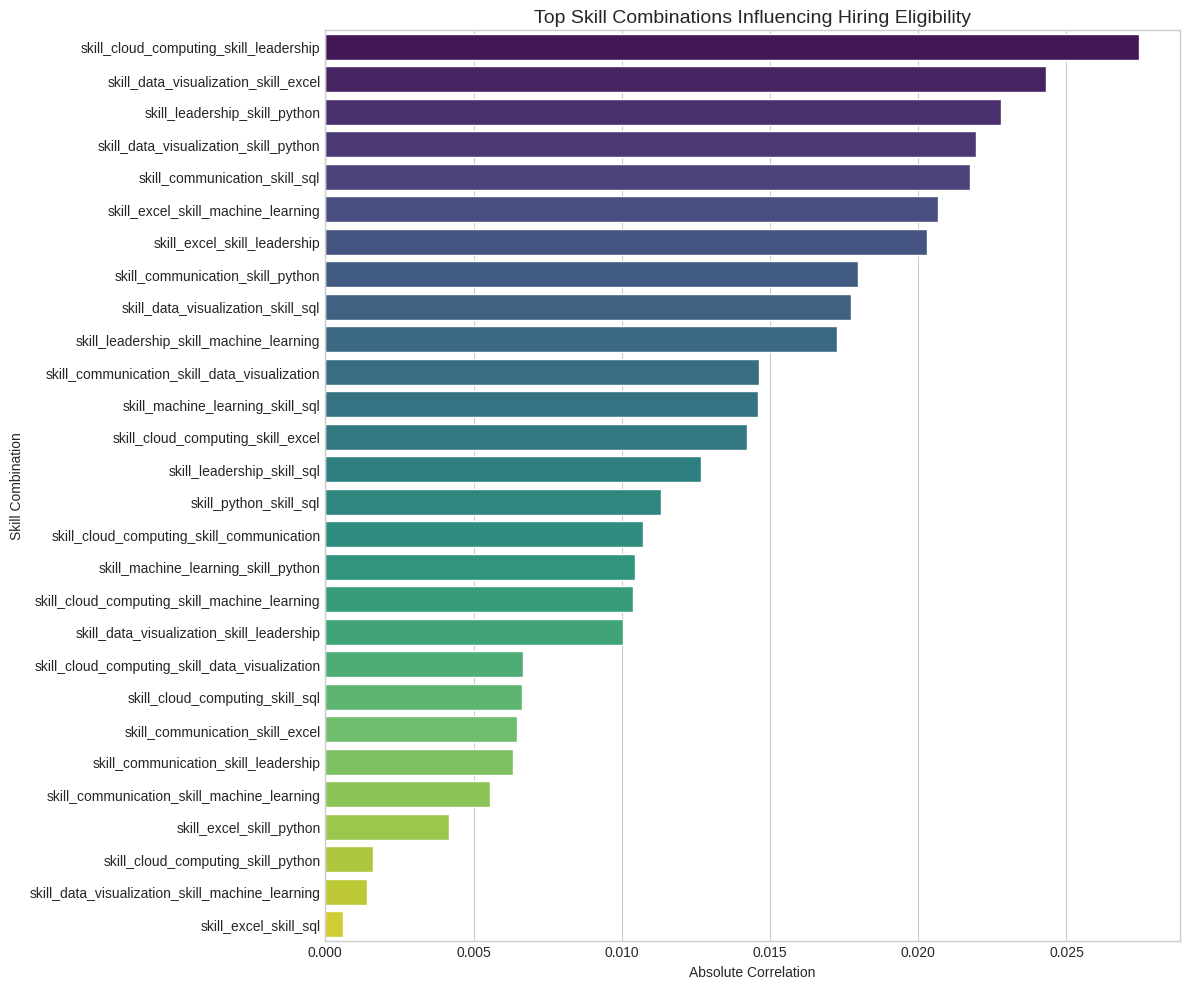

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# ==========================
# 28 KOLON KOMBINASI SKILL
# ==========================

# Daftar skill yang sudah diekstraksi (as defined in cell 4d5KeBW9ccOz)
skill_columns = [
    'skill_cloud_computing',
    'skill_communication',
    'skill_data_visualization',
    'skill_excel',
    'skill_leadership',
    'skill_machine_learning',
    'skill_python',
    'skill_sql'
]

# Generate the correct combination column names based on cell 4d5KeBW9ccOz logic
combination_columns = []
for skill1, skill2 in combinations(skill_columns, 2):
    combination_columns.append(f"{skill1}_{skill2}")

# ==========================
# KORELASI DENGAN TARGET
# ==========================

korelasi_target = df_drop[
    combination_columns + ['hiring_eligibility']
].corr()['hiring_eligibility'].drop('hiring_eligibility')

# Nilai absolut untuk mengurutkan kekuatan korelasi
faktor_pengaruh = korelasi_target.abs().sort_values(ascending=False)

# ==========================
# MENAMPILKAN HASIL
# ==========================

print("--- URUTAN KOMBINASI SKILL YANG PALING MEMENGARUHI ELIGIBILITY ---")

for rank, (fitur, nilai) in enumerate(faktor_pengaruh.items(), 1):

    nilai_asli = korelasi_target[fitur]

    arah = "Positif (+)" if nilai_asli > 0 else "Negatif (-)"

    print(
        f"{rank}. {fitur:<45} : "
        f"Kekuatan Pengaruh = {nilai:.4f} ({arah})"
    )

# ==========================
# VISUALISASI BARPLOT
# ==========================

plt.figure(figsize=(12, 10))

sns.barplot(
    x=faktor_pengaruh.values,
    y=faktor_pengaruh.index,
    palette='viridis',
    hue=faktor_pengaruh.index,
    legend=False
)

plt.title(
    'Top Skill Combinations Influencing Hiring Eligibility',
    fontsize=14
)

plt.xlabel('Absolute Correlation')
plt.ylabel('Skill Combination')

plt.tight_layout()
plt.show()

#**Splitting data**

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Pisahkan Fitur (X) dan Target Variable (y)
# Drop kolom target 'hiring_eligibility' untuk dijadikan X
X = df_drop.drop(columns=['hiring_eligibility'])
y = df_drop['hiring_eligibility']

# 2. Lakukan Pembagian Data (Splitting Data)
# Proporsi standar: 80% Train Set dan 20% Test Set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Cek jumlah baris dan kolom hasil split
print("--- HASIL SPLITTING DATA ---")
print(f"Dimensi X_train (Data Fitur Latihan) : {X_train.shape}")
print(f"Dimensi X_test (Data Fitur Ujian)    : {X_test.shape}")
print(f"Dimensi y_train (Data Target Latihan): {y_train.shape}")
print(f"Dimensi y_test (Data Target Ujian)   : {y_test.shape}")

--- HASIL SPLITTING DATA ---
Dimensi X_train (Data Fitur Latihan) : (4000, 51)
Dimensi X_test (Data Fitur Ujian)    : (1000, 51)
Dimensi y_train (Data Target Latihan): (4000,)
Dimensi y_test (Data Target Ujian)   : (1000,)


#**Scaling data**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Tentukan Kolom Numerik yang Di-scaling
# Kolom biner (0/1) hasil encoding & extraction TIDAK di-scaling
numerical_features = [
    'years_experience',
    'num_relevant_skills',
    'interview_score',
    'technical_test_score',
    'soft_skill_score'
]

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Menghitung rata-rata & std dari data Train, lalu mengubah skalanya
X_train_scaled = X_train.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])

# Hanya mengubah skala data Test menggunakan rumus yang didapat dari data Train (tanpa fit ulang)
X_test_scaled = X_test.copy()
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

# Cek Hasil Scaling
print("--- SCALING ---")
print("Data X_train after scaling:")
display(X_train_scaled[numerical_features].head())

--- SCALING ---
Data X_train after scaling:


,years_experience,num_relevant_skills,interview_score,technical_test_score,soft_skill_score
1769,0.962507,0.435751,1.615836,-0.515354,1.069408
4665,0.086983,-0.458556,1.048328,1.481285,0.458032
1147,-1.664065,-0.458556,-1.436437,1.200988,-0.036521
308,0.437193,-1.352862,1.696361,1.650232,-0.682944
4262,-0.788541,1.330057,0.365785,-0.188980,-1.555226


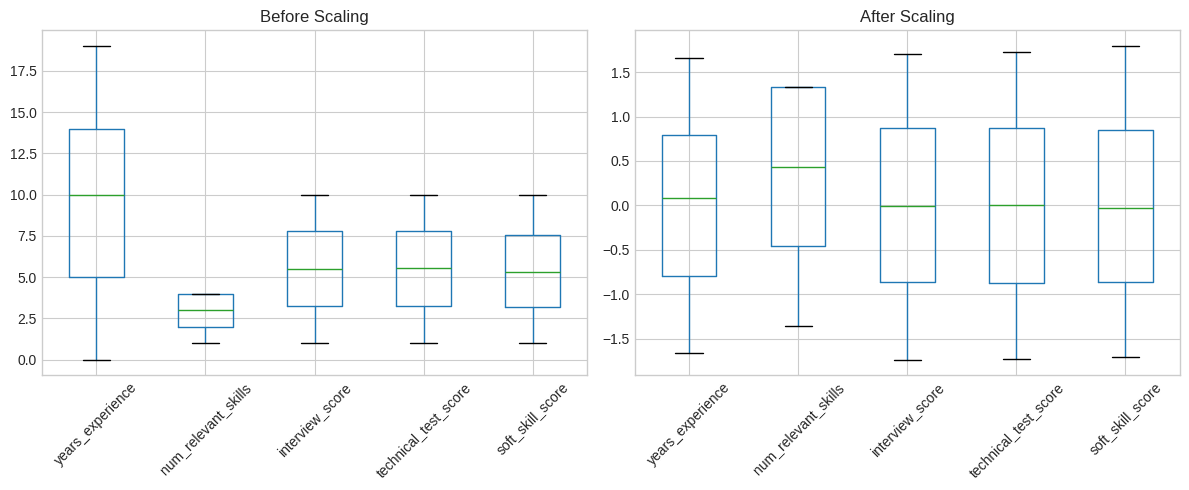

In [ ]:
import matplotlib.pyplot as plt

# Visualisasi Scaling
numeric_cols = [
    'years_experience',
    'num_relevant_skills',
    'interview_score',
    'technical_test_score',
    'soft_skill_score'
]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Sebelum Scaling
X_train[numeric_cols].boxplot(ax=axes[0])
axes[0].set_title('Before Scaling')
axes[0].tick_params(axis='x', rotation=45)

# Sesudah Scaling
X_train_scaled[numeric_cols].boxplot(ax=axes[1])
axes[1].set_title('After Scaling')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#**Imbalance data**

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Cek proporsi kelas target SEBELUM SMOTE pada data Train
print("--- SEBELUM BALANCING (SMOTE) ---")
print(f"Distribusi target data latih asli: {Counter(y_train)}")

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Terapkan SMOTE HANYA pada X_train_scaled dan y_train
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# 4. Cek proporsi kelas target SESUDAH SMOTE pada data Train
print("\n--- SESUDAH BALANCING (SMOTE) ---")
print(f"Distribusi target data latih sekarang: {Counter(y_train_balanced)}")
print(f"Dimensi X_train_balanced sekarang    : {X_train_balanced.shape}")

--- SEBELUM BALANCING (SMOTE) ---
Distribusi target data latih asli: Counter({0: 2813, 1: 1187})

--- SESUDAH BALANCING (SMOTE) ---
Distribusi target data latih sekarang: Counter({0: 2813, 1: 2813})
Dimensi X_train_balanced sekarang    : (5626, 51)


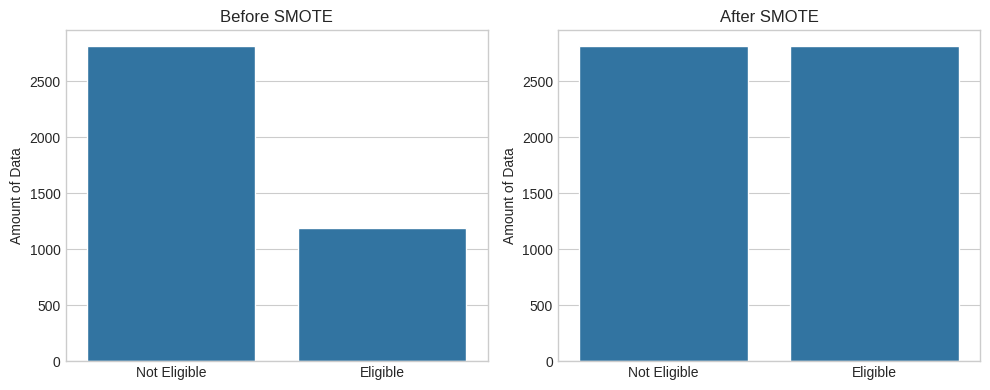

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

before = [2813, 1187]
after = [2813, 2813]

fig, axes = plt.subplots(1,2, figsize=(10,4))

sns.barplot(
    x=['Not Eligible','Eligible'],
    y=before,
    ax=axes[0]
)

axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Amount of Data')

sns.barplot(
    x=['Not Eligible','Eligible'],
    y=after,
    ax=axes[1]
)

axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Amount of Data')

plt.tight_layout()
plt.show()